In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

dataset = pd.read_csv("dataset/nps_simulated_dataset_gaussiano_2025-10-27.csv")
print("Number of rows: ", dataset.shape[0])
print("Number of columns: ", dataset.shape[1])
#dataset.head(20)

Number of rows:  1000
Number of columns:  21


In [62]:
dataset.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   simulation_id                 1000 non-null   int64  
 1   sensor_id                     1000 non-null   int64  
 2   sensor_x                      1000 non-null   float64
 3   sensor_y                      1000 non-null   float64
 4   sensor_noise                  1000 non-null   float64
 5   sensor_height                 1000 non-null   float64
 6   sensor_is_fault               1000 non-null   bool   
 7   RH                            1000 non-null   float64
 8   humidify                      1000 non-null   bool   
 9   days_simulation               1000 non-null   int64  
 10  wind_type                     1000 non-null   object 
 11  wind_speed                    1000 non-null   float64
 12  wind_dir                      1000 non-null   object 
 13  stab

In [63]:
print(datset_copy.columns.tolist())


['simulation_id', 'sensor_id', 'sensor_x', 'sensor_y', 'sensor_noise', 'sensor_is_fault', 'RH', 'humidify', 'wind_type', 'wind_speed', 'stability_value', 'aerosol_type', 'source_x', 'source_y', 'source_h', 'emission_rate', 'real_concentration_name_file', 'wind_dir_cos', 'wind_dir_sin']


In [64]:
dataset.isnull().sum()

simulation_id                   0
sensor_id                       0
sensor_x                        0
sensor_y                        0
sensor_noise                    0
sensor_height                   0
sensor_is_fault                 0
RH                              0
humidify                        0
days_simulation                 0
wind_type                       0
wind_speed                      0
wind_dir                        0
stability_profile               0
stability_value                 0
aerosol_type                    0
source_x                        0
source_y                        0
source_h                        0
emission_rate                   0
real_concentration_name_file    0
dtype: int64

In [65]:
dataset.describe()

,simulation_id,sensor_id,sensor_x,sensor_y,sensor_noise,sensor_height,RH,days_simulation,wind_speed,source_x,source_y,source_h,emission_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.500000,4.500000,253.023000,245.948000,0.000254,2.244249,0.275200,10.0,3.927000,249.900000,252.200000,5.450300,0.005159
std,28.880514,2.873719,141.253527,146.729168,0.000149,0.429781,0.338898,0.0,1.774258,139.347651,153.614509,2.462122,0.002856
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.501436,0.000000,10.0,0.740000,2.000000,4.000000,1.110000,0.000100
25%,24.750000,2.000000,142.000000,122.000000,0.000100,1.881582,0.000000,10.0,2.595000,138.250000,111.500000,3.412500,0.002425
50%,49.500000,4.500000,257.500000,245.500000,0.000300,2.229192,0.000000,10.0,3.600000,255.000000,238.000000,5.620000,0.005500
75%,74.250000,7.000000,372.000000,370.000000,0.000400,2.611491,0.632500,10.0,5.267500,370.000000,395.500000,7.212500,0.007525
max,99.000000,9.000000,499.000000,499.000000,0.000500,2.998264,0.990000,10.0,7.880000,479.000000,498.000000,9.910000,0.009900


In [66]:
print(dataset["wind_dir"][1])
print(type(dataset["wind_dir"][1]))


307.1259975821876,66.50869002515887,11.953197183112138,31.0024571862753,314.43969138486653,83.10511802170663,332.8897103566182,46.721026324497295,331.365663728175,346.78940157160946,298.73060332170223,21.082052709307575,325.92610680083607,2.9409435478505905,335.58373854269524,34.863512661843494,298.31676145248287,334.73582107128044,7.046216982457488,75.10812567703783,131.63346102102122,67.3835654969801,321.8698361139546,312.71787162641334,21.795316469308283,338.3578845972848,11.504890612890069,280.31414740938965,321.0585209539016,39.06114338492367,30.97930793083991,341.6531122622577,51.50626502976224,326.3364282106978,53.458986476996216,13.27091818365017,352.5625403666535,2.4384820462932897,348.4373285827894,326.01364416177773,359.6794521568987,6.453788186008111,14.843043702781385,39.43944036846697,351.2611572779514,346.6926024577827,12.671938072628173,326.9930368165876,350.0953181415241,24.86660688297915,53.426157638710556,338.27846713274585,298.2968603450704,333.73174236927633,290.75

In [67]:
datset_copy = dataset.copy()

In [68]:
def convert_string_to_array(s):
    if isinstance(s, str):
        s = s.replace('[', '').replace(']', '')
        return np.fromstring(s, sep=',')
    return s

datset_copy["wind_dir"] = datset_copy["wind_dir"].apply(convert_string_to_array) #type: ignore
print(type(datset_copy['wind_dir'][0]))
print(datset_copy['wind_dir'][0][0], type(datset_copy['wind_dir'][0][0]))

<class 'numpy.ndarray'>
307.1259975821876 <class 'numpy.float64'>


In [69]:
datset_copy["wind_dir"]

0      [307.1259975821876, 66.50869002515887, 11.9531...
1      [307.1259975821876, 66.50869002515887, 11.9531...
2      [307.1259975821876, 66.50869002515887, 11.9531...
3      [307.1259975821876, 66.50869002515887, 11.9531...
4      [307.1259975821876, 66.50869002515887, 11.9531...
                             ...                        
995    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
996    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
997    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
998    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
999    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
Name: wind_dir, Length: 1000, dtype: object

In [70]:
datset_copy.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   simulation_id                 1000 non-null   int64  
 1   sensor_id                     1000 non-null   int64  
 2   sensor_x                      1000 non-null   float64
 3   sensor_y                      1000 non-null   float64
 4   sensor_noise                  1000 non-null   float64
 5   sensor_height                 1000 non-null   float64
 6   sensor_is_fault               1000 non-null   bool   
 7   RH                            1000 non-null   float64
 8   humidify                      1000 non-null   bool   
 9   days_simulation               1000 non-null   int64  
 10  wind_type                     1000 non-null   object 
 11  wind_speed                    1000 non-null   float64
 12  wind_dir                      1000 non-null   object 
 13  stab

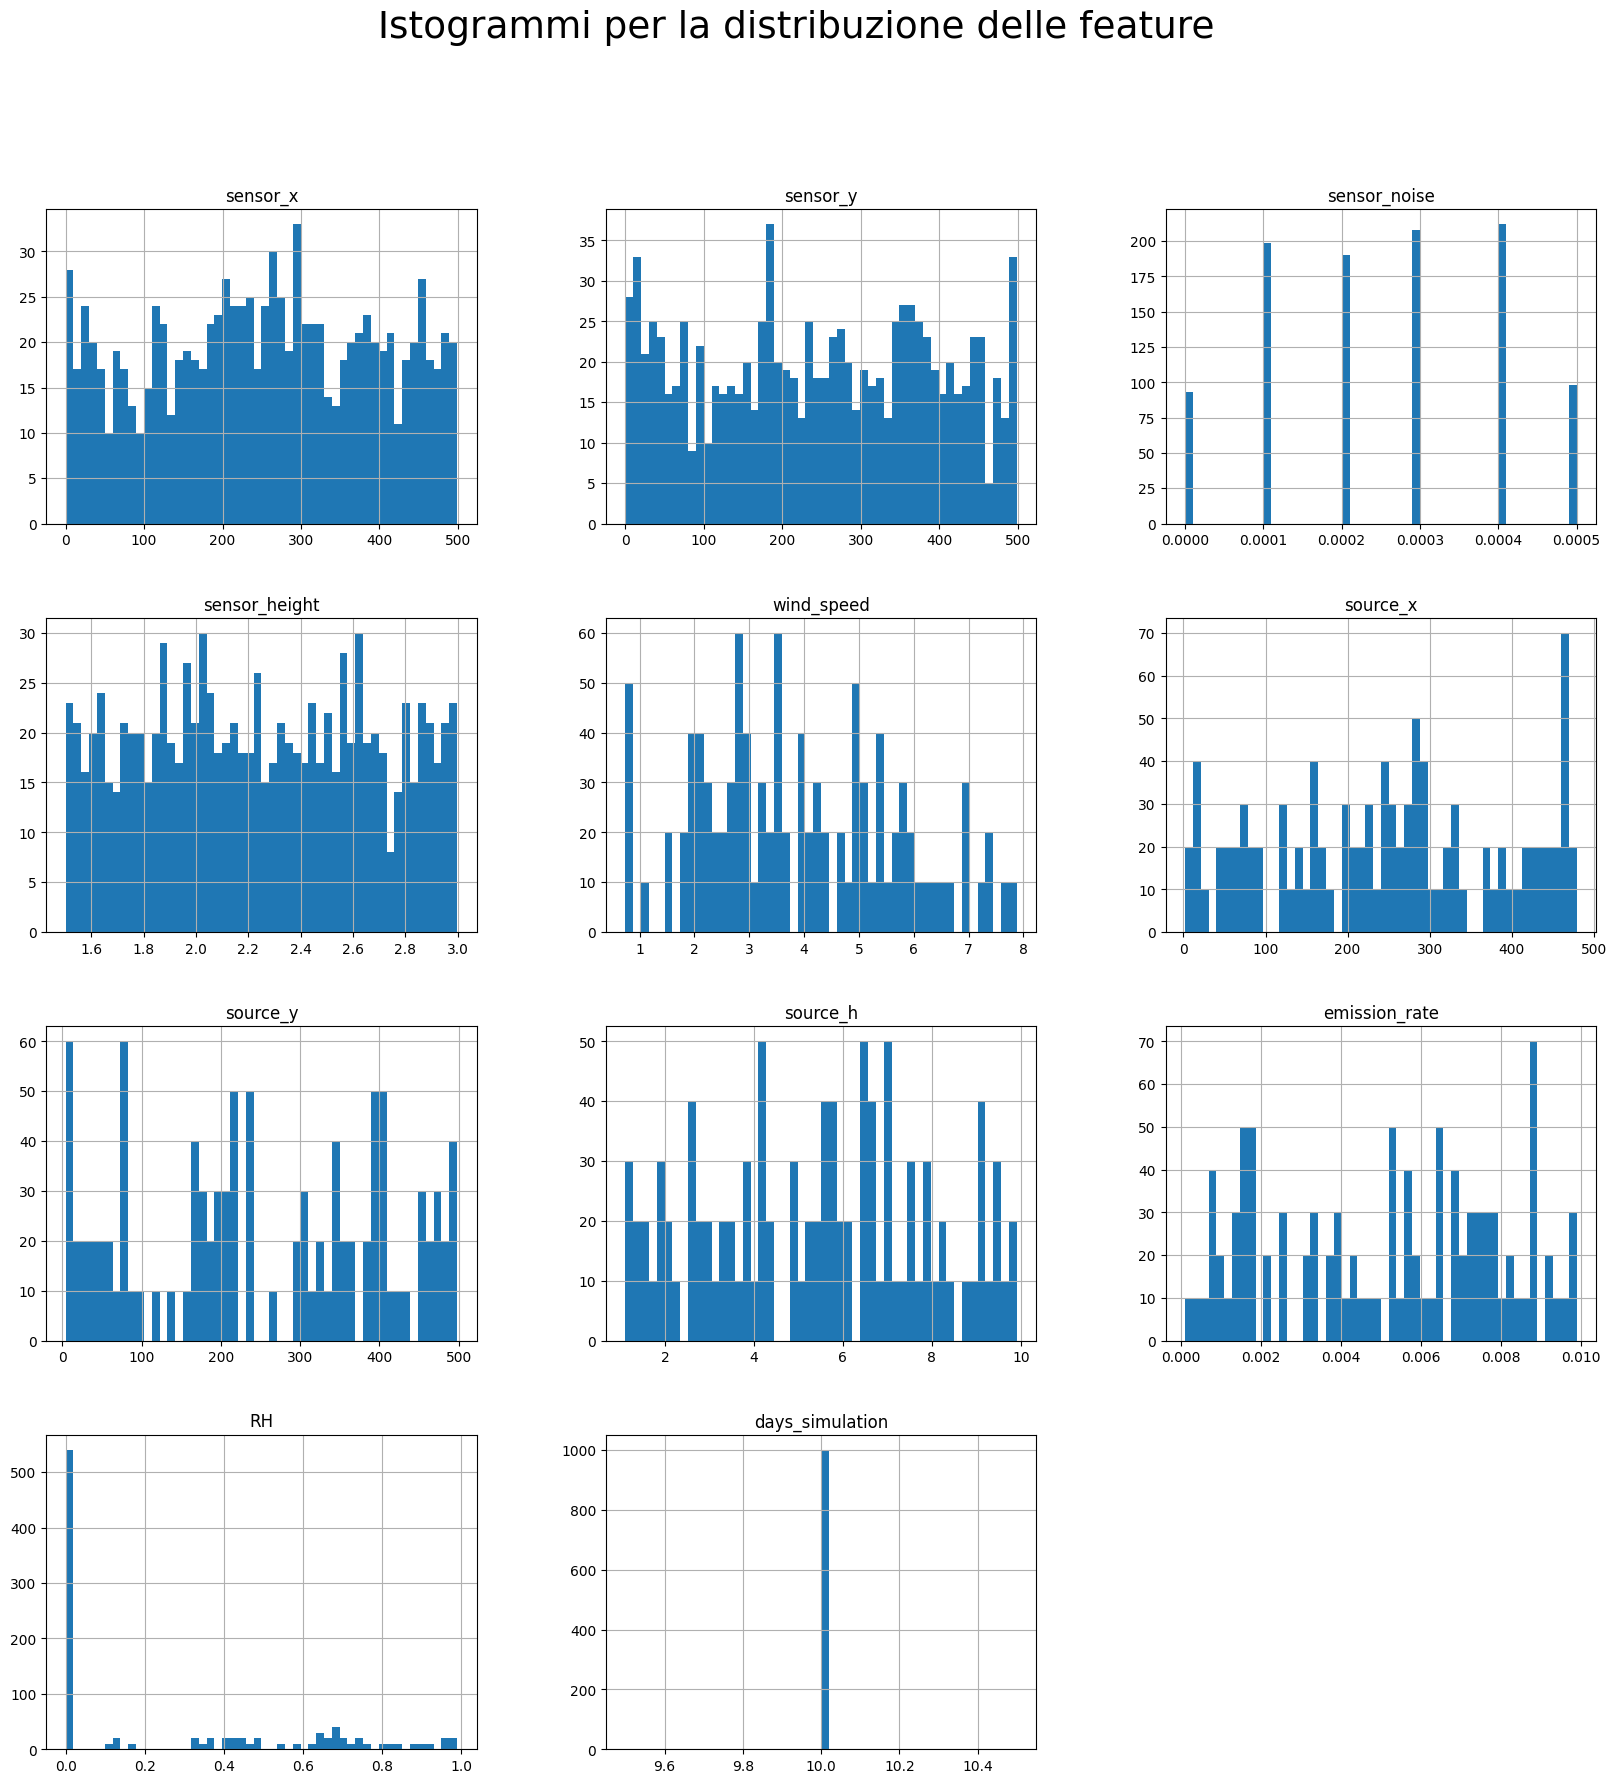

In [71]:
datset_copy_subset = datset_copy[[
    "sensor_x", "sensor_y", "sensor_noise", "sensor_height",
    "wind_speed", "source_x", "source_y", "source_h",
    "emission_rate", "RH", "days_simulation"
]]

datset_copy_subset.hist(figsize=(20, 20), bins=50)
plt.suptitle("Istogrammi per la distribuzione delle feature", fontsize=27)
plt.show()


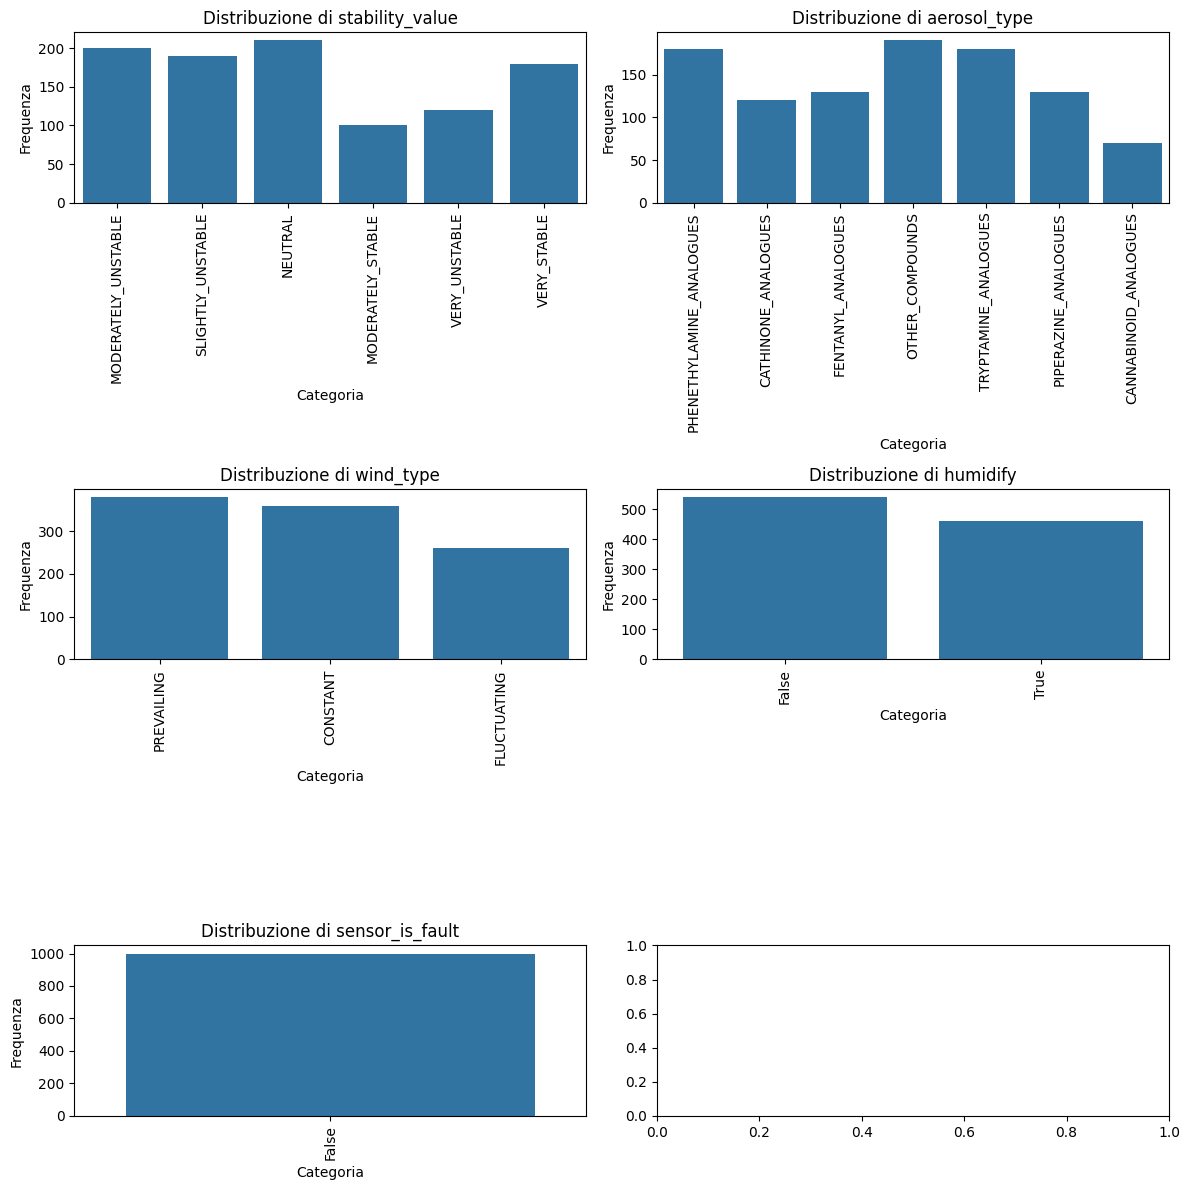

In [72]:
categorical_cols =[ "stability_value", "aerosol_type", "wind_type", "humidify", "sensor_is_fault"]

n_cols = 2
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()  

for i, col in enumerate(categorical_cols):
    sns.countplot(data=datset_copy, x=col, ax=axes[i])
    axes[i].set_title(f"Distribuzione di {col}")
    axes[i].set_xlabel("Categoria")
    axes[i].set_ylabel("Frequenza")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

In [73]:
datset_copy = datset_copy.drop(columns=[
    "stability_profile", "sensor_height", "days_simulation"
])
datset_copy.info(verbose=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   simulation_id                 1000 non-null   int64  
 1   sensor_id                     1000 non-null   int64  
 2   sensor_x                      1000 non-null   float64
 3   sensor_y                      1000 non-null   float64
 4   sensor_noise                  1000 non-null   float64
 5   sensor_is_fault               1000 non-null   bool   
 6   RH                            1000 non-null   float64
 7   humidify                      1000 non-null   bool   
 8   wind_type                     1000 non-null   object 
 9   wind_speed                    1000 non-null   float64
 10  wind_dir                      1000 non-null   object 
 11  stability_value               1000 non-null   object 
 12  aerosol_type                  1000 non-null   object 
 13  sour

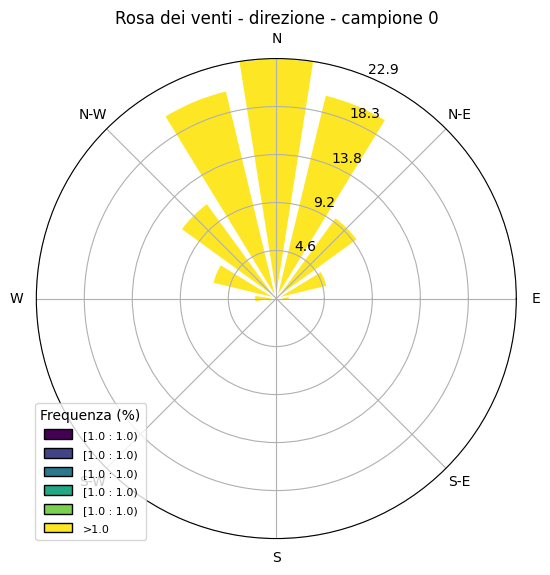

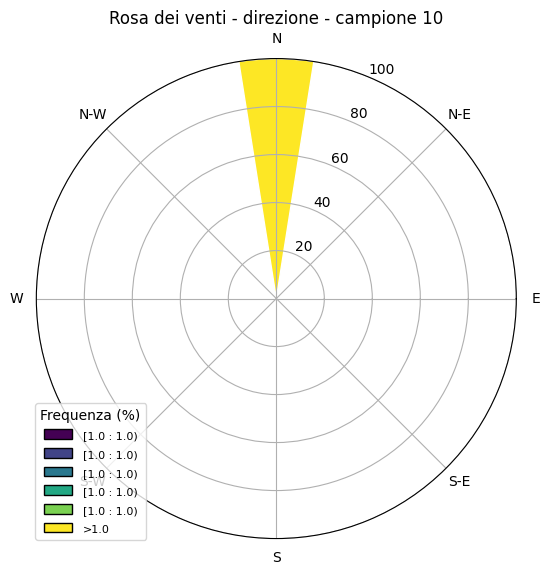

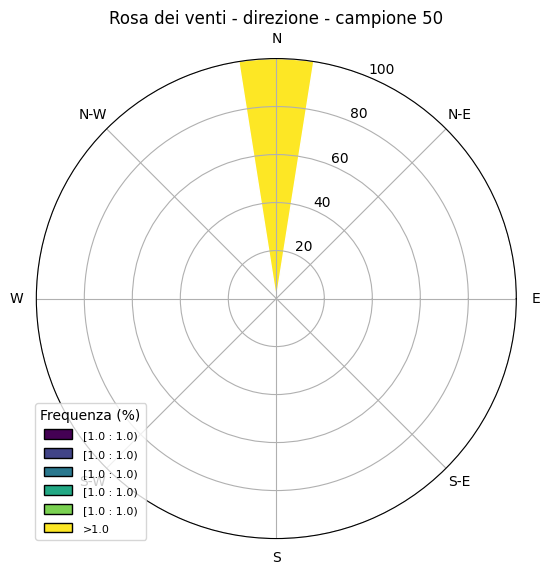

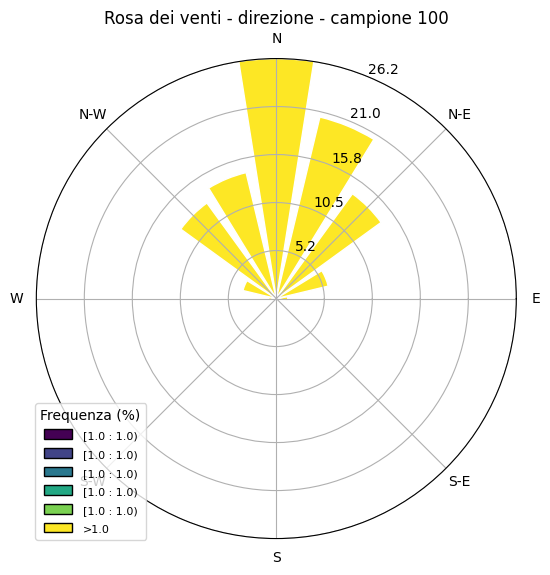

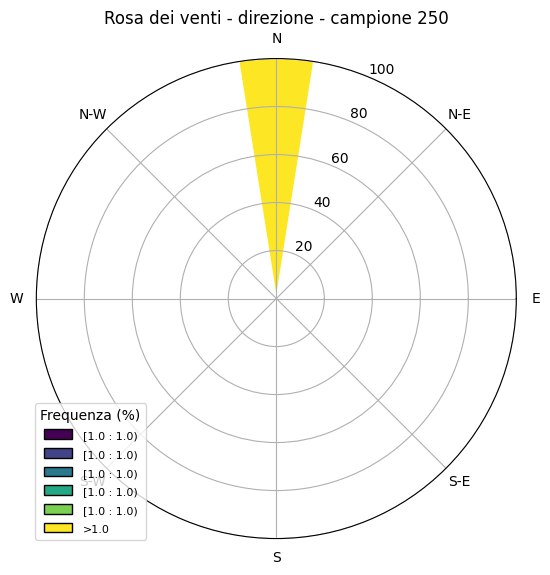

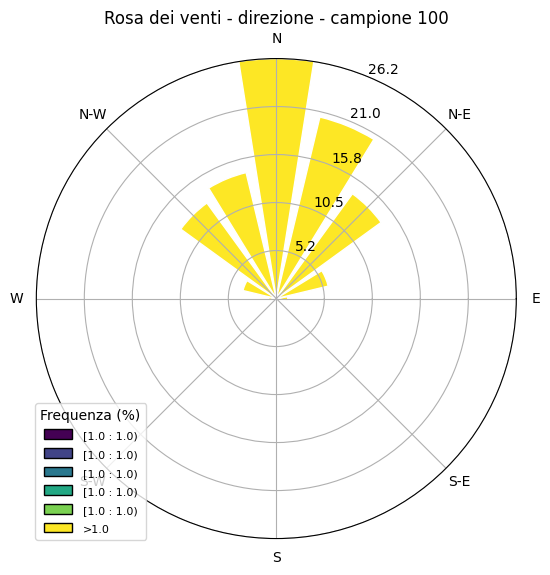

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

def plot_windrose_samples(dataset, indices):
    if isinstance(indices, int):
        indices = [indices]

    for i in indices:
        direzioni = np.array(dataset["wind_dir"].iloc[i])
        frequenze = np.ones_like(direzioni)  # peso uniforme per ogni direzione

        fig = plt.figure(figsize=(6,6))
        ax = WindroseAxes.from_ax(fig=fig)
        ax.bar(direzioni, frequenze, normed=True, opening=0.8, edgecolor='white')
        ax.set_legend(title="Frequenza (%)")
        ax.set_title(f"Rosa dei venti - direzione - campione {i}")
        plt.show()

plot_windrose_samples(datset_copy, [0, 10, 50, 100, 250, 100]) 

In [75]:
#Convert string arrays to numpy arrays and calculate mean direction for each entry
def calculate_mean_direction(wind_dir_array):
	
	# Convert to radians
	wind_dir_rad = np.radians(wind_dir_array)
	
	# Calculate directional vectors
	cos_vals = np.cos(wind_dir_rad)
	sin_vals = np.sin(wind_dir_rad)
	
	# Calculate mean
	mean_cos = np.mean(cos_vals)
	mean_sin = np.mean(sin_vals)
	
	return mean_cos, mean_sin

# Apply to all wind directions
mean_directions = np.array([calculate_mean_direction(wd) for wd in datset_copy["wind_dir"]])

# Save mean wind direction components to dataset
datset_copy['wind_dir_cos'] = mean_directions[:, 0]
datset_copy['wind_dir_sin'] = mean_directions[:, 1]

In [76]:
datset_copy.drop(columns=["wind_dir"], inplace=True)

In [77]:
datset_copy_corr = datset_copy.copy()

wind_type_map = {
    "CONSTANT": 1,
    "FLUCTUATING": 2,
    "PREVAILING": 3
}

pg_stability_map = {
    "PasquillGiffordStability.VERY_UNSTABLE": 1,
    "PasquillGiffordStability.MODERATELY_UNSTABLE": 2,
    "PasquillGiffordStability.SLIGHTLY_UNSTABLE": 3,
    "PasquillGiffordStability.NEUTRAL": 4,
    "PasquillGiffordStability.MODERATELY_STABLE": 5,
    "PasquillGiffordStability.VERY_STABLE": 6
}

nps_type_map = {
    "CANNABINOID_ANALOGUES": 0,
    "CATHINONE_ANALOGUES": 1,
    "PHENETHYLAMINE_ANALOGUES": 2,
    "PIPERAZINE_ANALOGUES": 3,
    "TRYPTAMINE_ANALOGUES": 4,
    "FENTANYL_ANALOGUES": 5,
    "OTHER_COMPOUNDS": 6
}


datset_copy_corr['wind_type'] = datset_copy_corr['wind_type'].astype(str)
datset_copy_corr['stability_value'] = datset_copy_corr['stability_value'].astype(str)
datset_copy_corr['aerosol_type'] = datset_copy_corr['aerosol_type'].astype(str)

datset_copy_corr['wind_type'] = datset_copy_corr['wind_type'].map(wind_type_map)
datset_copy_corr['stability_value'] = datset_copy_corr['stability_value'].map(pg_stability_map)
datset_copy_corr['aerosol_type'] = datset_copy_corr['aerosol_type'].map(nps_type_map)

datset_copy_corr[["wind_type", "stability_value", "aerosol_type"]].head()

,wind_type,stability_value,aerosol_type
0,3,NaN,2
1,3,NaN,2
2,3,NaN,2
3,3,NaN,2
4,3,NaN,2


In [78]:
datset_copy_corr.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   simulation_id                 1000 non-null   int64  
 1   sensor_id                     1000 non-null   int64  
 2   sensor_x                      1000 non-null   float64
 3   sensor_y                      1000 non-null   float64
 4   sensor_noise                  1000 non-null   float64
 5   sensor_is_fault               1000 non-null   bool   
 6   RH                            1000 non-null   float64
 7   humidify                      1000 non-null   bool   
 8   wind_type                     1000 non-null   int64  
 9   wind_speed                    1000 non-null   float64
 10  stability_value               0 non-null      float64
 11  aerosol_type                  1000 non-null   int64  
 12  source_x                      1000 non-null   float64
 13  sour

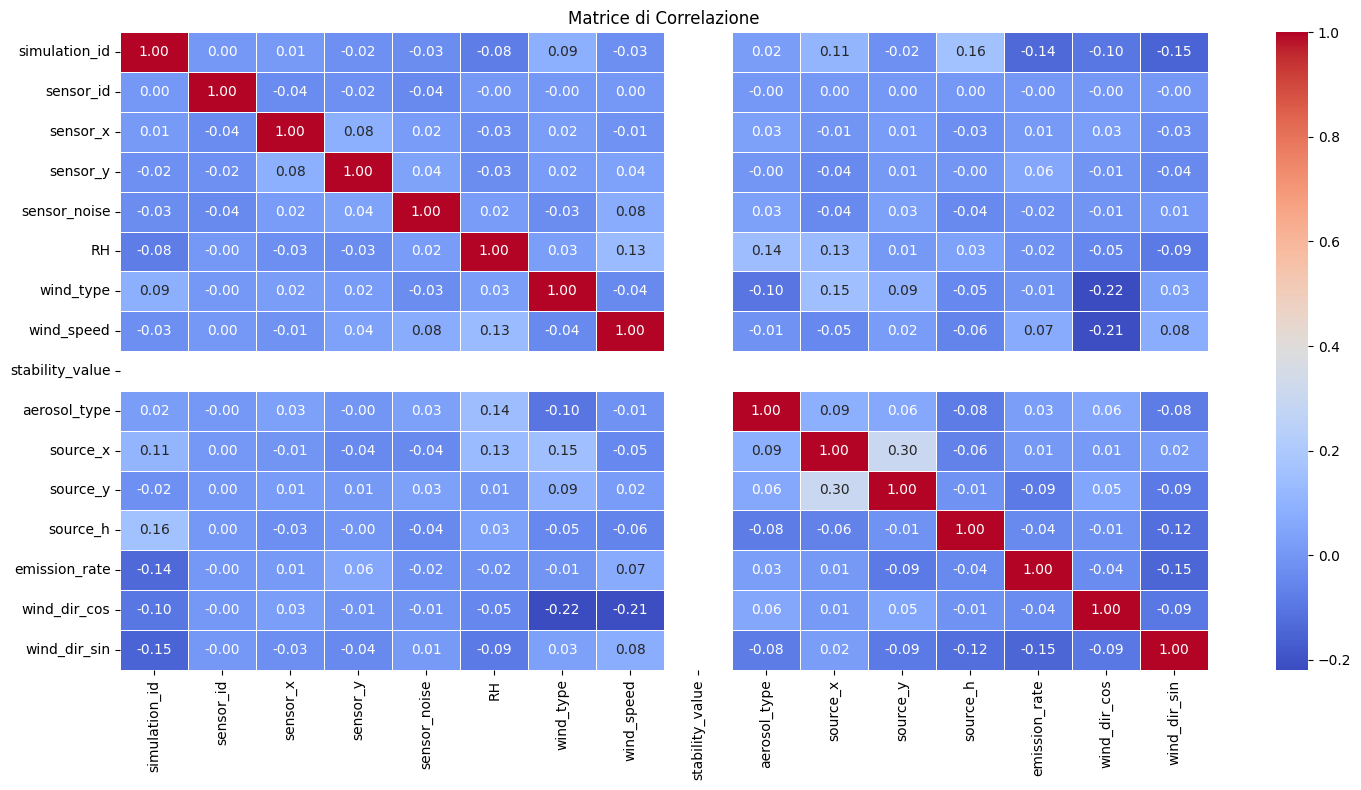

In [79]:
numeric_cols = datset_copy_corr.select_dtypes(include=[np.number])
matrix_corr = numeric_cols.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(matrix_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice di Correlazione")
plt.tight_layout()
plt.show()


In [80]:
datset_copy.drop(columns=["humidify"], inplace=True)
datset_copy.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   simulation_id                 1000 non-null   int64  
 1   sensor_id                     1000 non-null   int64  
 2   sensor_x                      1000 non-null   float64
 3   sensor_y                      1000 non-null   float64
 4   sensor_noise                  1000 non-null   float64
 5   sensor_is_fault               1000 non-null   bool   
 6   RH                            1000 non-null   float64
 7   wind_type                     1000 non-null   object 
 8   wind_speed                    1000 non-null   float64
 9   stability_value               1000 non-null   object 
 10  aerosol_type                  1000 non-null   object 
 11  source_x                      1000 non-null   float64
 12  source_y                      1000 non-null   float64
 13  sour

In [81]:
from sklearn.preprocessing import LabelEncoder

le_wind_type = LabelEncoder()
le_aerosol = LabelEncoder()
le_stability = LabelEncoder()

le_wind_type.fit(datset_copy['wind_type'])
le_aerosol.fit(datset_copy['aerosol_type'])
le_stability.fit(datset_copy['stability_value'])

datset_copy['wind_type']=le_wind_type.transform(datset_copy['wind_type'])
datset_copy['aerosol_type']=le_aerosol.transform(datset_copy['aerosol_type'])
datset_copy['stability_value']=le_stability.transform(datset_copy['stability_value'])

In [82]:
# save dataset_copy to a new CSV file
datset_copy.to_csv("dataset/nps_simulated_dataset_gaussiano_2025-10-27_processed.csv", index=False)